# Step 4: Time-aware Stream Preparation

This notebook reads the 5-second ECG segments generated in Step 3, performs segment-level checks and simple EDA, and fixes the time-aware stream order for later online learning.

The main experiment stream order is fixed as `week_number -> record_number -> segment_index_within_record`.


In [1]:
# Cell 1: paths and imports

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# project root
PROJECT_ROOT = Path("F:/ECG")

# Step 3 and Step 4 artifacts live under data/processed
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Step 4 input: outputs from Step 3
SEGMENT_METADATA_PATH = PROCESSED_DIR / "segment_metadata_sit_5s.csv"
X_SEGMENTS_PATH = PROCESSED_DIR / "X_segments_sit_5s.npy"
Y_SEGMENTS_PATH = PROCESSED_DIR / "y_segments_sit_5s.npy"

# Step 4 output: time-aware stream order and metadata
STREAM_ORDER_TIME_PATH = PROCESSED_DIR / "stream_order_time_sit_5s.npy"
STREAM_METADATA_TIME_PATH = PROCESSED_DIR / "stream_metadata_time_sit_5s.csv"

# Print shapes
EXPECTED_X_SHAPE = (36103, 1000)
EXPECTED_Y_SHAPE = (36103,)

print("Step 4 input segment metadata:", SEGMENT_METADATA_PATH)
print("Step 4 input X_segments:", X_SEGMENTS_PATH)
print("Step 4 input y_segments:", Y_SEGMENTS_PATH)
print("Step 4 output stream order:", STREAM_ORDER_TIME_PATH)
print("Step 4 output stream metadata:", STREAM_METADATA_TIME_PATH)


Step 4 input segment metadata: F:\ECG\data\processed\segment_metadata_sit_5s.csv
Step 4 input X_segments: F:\ECG\data\processed\X_segments_sit_5s.npy
Step 4 input y_segments: F:\ECG\data\processed\y_segments_sit_5s.npy
Step 4 output stream order: F:\ECG\data\processed\stream_order_time_sit_5s.npy
Step 4 output stream metadata: F:\ECG\data\processed\stream_metadata_time_sit_5s.csv


In [3]:
# Cell 2: load Step 3 outputs

# CSV segment metadata
segment_metadata = pd.read_csv(SEGMENT_METADATA_PATH)

# NPY ECG segment arrays and labels
X_segments = np.load(X_SEGMENTS_PATH)
y_segments = np.load(Y_SEGMENTS_PATH)

print("segment_metadata shape:", segment_metadata.shape)
print("X_segments shape:", X_segments.shape)
print("y_segments shape:", y_segments.shape)
print("Step 3 outputs loaded.")


segment_metadata shape: (36103, 11)
X_segments shape: (36103, 1000)
y_segments shape: (36103,)
Step 3 outputs loaded.


In [5]:
# Cell 3: validate metadata, X_segments, and y_segments shapes

metadata_count = len(segment_metadata)
X_count = X_segments.shape[0]
y_count = y_segments.shape[0]

same_count = (metadata_count == X_count == y_count)
X_shape_is_expected = (X_segments.shape == EXPECTED_X_SHAPE)
y_shape_is_expected = (y_segments.shape == EXPECTED_Y_SHAPE)

print("segment_metadata row count:", metadata_count)
print("X_segments count:", X_count)
print("y_segments count:", y_count)
print("all three counts match:", same_count)
print("X_segments shape is (36103, 1000):", X_shape_is_expected)
print("y_segments shape is (36103,):", y_shape_is_expected)

if not same_count:
    raise ValueError("segment_metadata, X_segments, and y_segments are inconsistent. Please rerun Step 3.")

if not X_shape_is_expected:
    raise ValueError(f"X_segments shape does not match the current version requirement; actual shape = {X_segments.shape}")

if not y_shape_is_expected:
    raise ValueError(f"y_segments shape does not match the current version requirement; actual shape = {y_segments.shape}")


segment_metadata row count: 36103
X_segments count: 36103
y_segments count: 36103
all three counts match: True
X_segments shape is (36103, 1000): True
y_segments shape is (36103,): True


In [7]:
# Cell 4: inspect X_segments, y_segments, and segment_metadata

X_nan_count = int(np.isnan(X_segments).sum())
X_inf_count = int(np.isinf(X_segments).sum())
y_nan_count = int(np.isnan(y_segments).sum())
metadata_missing_by_column = segment_metadata.isna().sum()
metadata_missing_total = int(metadata_missing_by_column.sum())

print("NaN count in X_segments:", X_nan_count)
print("Inf count in X_segments:", X_inf_count)
print("NaN count in y_segments:", y_nan_count)
print("total missing values in segment_metadata:", metadata_missing_total)
print("missing value count per segment_metadata column:")
display(metadata_missing_by_column)

if X_nan_count != 0:
    raise ValueError("X_segments contains NaN.")

if X_inf_count != 0:
    raise ValueError("X_segments contains Inf.")

if y_nan_count != 0:
    raise ValueError("y_segments contains NaN.")

if metadata_missing_total != 0:
    raise ValueError("segment_metadata contains missing values.")


NaN count in X_segments: 0
Inf count in X_segments: 0
NaN count in y_segments: 0
total missing values in segment_metadata: 0
missing value count per segment_metadata column:


segment_id                     0
record_number                  0
subject_id                     0
week_number                    0
condition_number               0
condition_name                 0
segment_index_within_record    0
start_sample                   0
end_sample                     0
start_time_seconds             0
end_time_seconds               0
dtype: int64

In [9]:
# Cell 5: preview the first 10 segment_metadata rows

segment_metadata.head(10)


,segment_id,record_number,subject_id,week_number,condition_number,condition_name,segment_index_within_record,start_sample,end_sample,start_time_seconds,end_time_seconds
0,0,1,1,1,1,sit,0,0,1000,0.0,5.0
1,1,1,1,1,1,sit,1,1000,2000,5.0,10.0
2,2,1,1,1,1,sit,2,2000,3000,10.0,15.0
3,3,1,1,1,1,sit,3,3000,4000,15.0,20.0
4,4,1,1,1,1,sit,4,4000,5000,20.0,25.0
5,5,1,1,1,1,sit,5,5000,6000,25.0,30.0
6,6,1,1,1,1,sit,6,6000,7000,30.0,35.0
7,7,1,1,1,1,sit,7,7000,8000,35.0,40.0
8,8,1,1,1,1,sit,8,8000,9000,40.0,45.0
9,9,1,1,1,1,sit,9,9000,10000,45.0,50.0


In [11]:
# Cell 6: subject-level segment distribution and label imbalance

# Count 5-second segments per subject_id
segments_per_subject = segment_metadata["subject_id"].value_counts().sort_index()

# describe() returns count, mean, std, min, and max
subject_distribution_summary = segments_per_subject.describe()

# top 10 subjects with the most segments
top_10_subjects = segments_per_subject.sort_values(ascending=False).head(10)

# bottom 10 subjects with the fewest segments
bottom_10_subjects = segments_per_subject.sort_values(ascending=True).head(10)

print("segment count per subject describe():")
display(subject_distribution_summary)

print("top 10 subjects with the most segments:")
display(top_10_subjects)

print("bottom 10 subjects with the fewest segments:")
display(bottom_10_subjects)


segment count per subject describe():


count    1019.000000
mean       35.429833
std        39.869923
min         5.000000
25%        12.000000
50%        24.000000
75%        36.000000
max       240.000000
Name: count, dtype: float64

top 10 subjects with the most segments:


subject_id
781    240
818    240
660    236
855    228
837    228
821    228
872    228
596    216
681    216
788    216
Name: count, dtype: int64

bottom 10 subjects with the fewest segments:


subject_id
8       5
511    12
303    12
302    12
455    12
300    12
299    12
298    12
297    12
296    12
Name: count, dtype: int64

In [13]:
# Cell 7: week-level segment distribution

# Count 5-second segments per week
segments_per_week = segment_metadata["week_number"].value_counts().sort_index()

print("segment count per week:")
display(segments_per_week)

print("segment count per week describe():")
display(segments_per_week.describe())


segment count per week:


week_number
1    25555
2     1728
3     1824
4     3480
6     3516
Name: count, dtype: int64

segment count per week describe():


count        5.000000
mean      7220.600000
std      10285.406156
min       1728.000000
25%       1824.000000
50%       3480.000000
75%       3516.000000
max      25555.000000
Name: count, dtype: float64

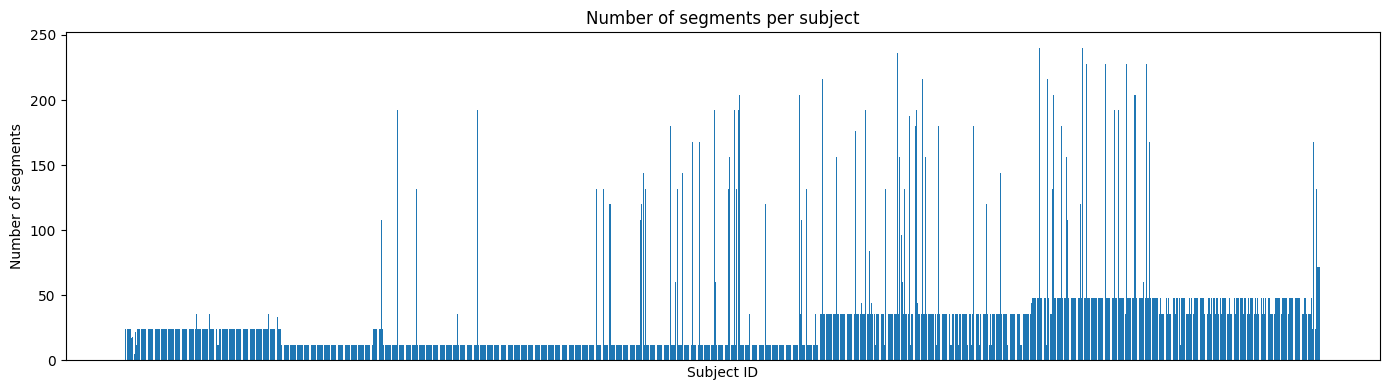

In [15]:
# Cell 8: plot number of segments per subject

plt.figure(figsize=(14, 4))
plt.bar(segments_per_subject.index.astype(str), segments_per_subject.values)
plt.title("Number of segments per subject")
plt.xlabel("Subject ID")
plt.ylabel("Number of segments")

# Sort subjects so the x-axis is stable and readable
plt.xticks([])
plt.tight_layout()
plt.show()


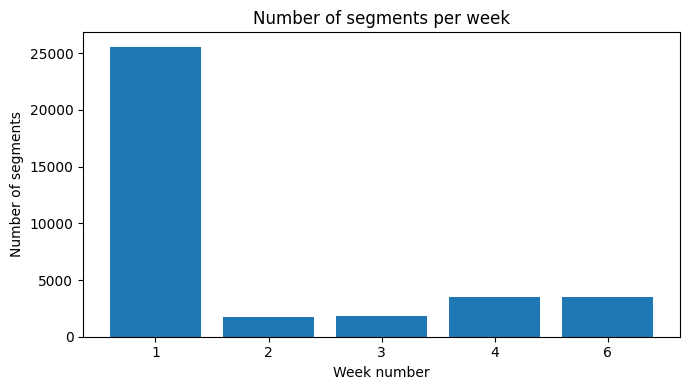

In [17]:
# Cell 9: plot number of segments per week

plt.figure(figsize=(7, 4))
plt.bar(segments_per_week.index.astype(str), segments_per_week.values)
plt.title("Number of segments per week")
plt.xlabel("Week number")
plt.ylabel("Number of segments")
plt.tight_layout()
plt.show()


In [19]:
# Cell 10: build the time-aware stream order

# Principle:
# week_number -> record_number -> segment_index_within_record
# Do not use a shuffled stream here; keep the seed42 shuffle for comparison only.

required_columns = [
    "segment_id",
    "week_number",
    "record_number",
    "segment_index_within_record",
]

missing_columns = []
for column in required_columns:
    if column not in segment_metadata.columns:
        missing_columns.append(column)

if len(missing_columns) > 0:
    raise ValueError(f"segment_metadata is missing required columns: {missing_columns}")

# segment_id should align with X_segments and y_segments
# Step 3 segment_id values should be zero-based and contiguous.
segment_id_values = segment_metadata["segment_id"].to_numpy()
expected_segment_id_values = np.arange(len(segment_metadata))
segment_id_matches_row_index = np.array_equal(segment_id_values, expected_segment_id_values)

print("segment_id equals original row index:", segment_id_matches_row_index)

if not segment_id_matches_row_index:
    raise ValueError("segment_id is not zero-based or does not match X_segments/y_segments.")

# Save the time-aware stream order
stream_metadata_time = segment_metadata.sort_values(
    by=["week_number", "record_number", "segment_index_within_record"],
    ascending=[True, True, True],
    kind="mergesort",
).reset_index(drop=True)

# stream_order_time stores segment_id values.
# Use it to index X_segments[stream_order_time] and y_segments[stream_order_time].
stream_order_time = stream_metadata_time["segment_id"].to_numpy(dtype=np.int64)

print("stream_metadata_time shape:", stream_metadata_time.shape)
print("stream_order_time shape:", stream_order_time.shape)
print("first 20 segment_id values in stream_order_time:")
print(stream_order_time[:20])

print("first 10 metadata rows in the time-aware stream:")
display(stream_metadata_time.head(10))


segment_id equals original row index: True
stream_metadata_time shape: (36103, 11)
stream_order_time shape: (36103,)
first 20 segment_id values in stream_order_time:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
first 10 metadata rows in the time-aware stream:


,segment_id,record_number,subject_id,week_number,condition_number,condition_name,segment_index_within_record,start_sample,end_sample,start_time_seconds,end_time_seconds
0,0,1,1,1,1,sit,0,0,1000,0.0,5.0
1,1,1,1,1,1,sit,1,1000,2000,5.0,10.0
2,2,1,1,1,1,sit,2,2000,3000,10.0,15.0
3,3,1,1,1,1,sit,3,3000,4000,15.0,20.0
4,4,1,1,1,1,sit,4,4000,5000,20.0,25.0
5,5,1,1,1,1,sit,5,5000,6000,25.0,30.0
6,6,1,1,1,1,sit,6,6000,7000,30.0,35.0
7,7,1,1,1,1,sit,7,7000,8000,35.0,40.0
8,8,1,1,1,1,sit,8,8000,9000,40.0,45.0
9,9,1,1,1,1,sit,9,9000,10000,45.0,50.0


In [21]:
# Cell 11: save and reload Step 4 artifacts

# Reload Step 4 outputs for validation Step 3 outputs loaded.
stream_metadata_time.to_csv(STREAM_METADATA_TIME_PATH, index=False)
np.save(STREAM_ORDER_TIME_PATH, stream_order_time)

# Reload Step 4 outputs for validation
stream_metadata_time_reloaded = pd.read_csv(STREAM_METADATA_TIME_PATH)
stream_order_time_reloaded = np.load(STREAM_ORDER_TIME_PATH)

print("saved stream_metadata_time:", STREAM_METADATA_TIME_PATH)
print("saved stream_order_time:", STREAM_ORDER_TIME_PATH)
print("reloaded stream_metadata_time shape:", stream_metadata_time_reloaded.shape)
print("reloaded stream_order_time shape:", stream_order_time_reloaded.shape)
print("stream metadata row count matches after reload:", len(stream_metadata_time_reloaded) == len(stream_metadata_time))
print("stream order matches after reload:", np.array_equal(stream_order_time_reloaded, stream_order_time))


saved stream_metadata_time: F:\ECG\data\processed\stream_metadata_time_sit_5s.csv
saved stream_order_time: F:\ECG\data\processed\stream_order_time_sit_5s.npy
reloaded stream_metadata_time shape: (36103, 11)
reloaded stream_order_time shape: (36103,)
stream metadata row count matches after reload: True
stream order matches after reload: True


In [23]:
# Cell 12:Step 4 Summary

raw_segment_total = len(segment_metadata)
stream_metadata_time_rows = len(stream_metadata_time)
stream_order_time_length = len(stream_order_time)
unique_subject_count = segment_metadata["subject_id"].nunique()
week_segment_counts = stream_metadata_time["week_number"].value_counts().sort_index()

all_counts_are_consistent = (
    raw_segment_total == X_segments.shape[0]
    and raw_segment_total == y_segments.shape[0]
    and raw_segment_total == stream_metadata_time_rows
    and raw_segment_total == stream_order_time_length
)

print("Step 4 Summary")
print("raw segment total:", raw_segment_total)
print("stream_metadata_time row count:", stream_metadata_time_rows)
print("stream_order_time length:", stream_order_time_length)
print("X_segments shape:", X_segments.shape)
print("y_segments shape:", y_segments.shape)
print("unique subject count:", unique_subject_count)
print("metadata, X, y, and stream_order are consistent:", all_counts_are_consistent)
print("first 20 segment_id values in stream_order_time:")
print(stream_order_time[:20])

print("segment count per week:")
display(week_segment_counts)

print("first 10 metadata rows in the time-aware stream:")
display(stream_metadata_time.head(10))


Step 4 Summary
raw segment total: 36103
stream_metadata_time row count: 36103
stream_order_time length: 36103
X_segments shape: (36103, 1000)
y_segments shape: (36103,)
unique subject count: 1019
metadata, X, y, and stream_order are consistent: True
first 20 segment_id values in stream_order_time:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
segment count per week:


week_number
1    25555
2     1728
3     1824
4     3480
6     3516
Name: count, dtype: int64

first 10 metadata rows in the time-aware stream:


,segment_id,record_number,subject_id,week_number,condition_number,condition_name,segment_index_within_record,start_sample,end_sample,start_time_seconds,end_time_seconds
0,0,1,1,1,1,sit,0,0,1000,0.0,5.0
1,1,1,1,1,1,sit,1,1000,2000,5.0,10.0
2,2,1,1,1,1,sit,2,2000,3000,10.0,15.0
3,3,1,1,1,1,sit,3,3000,4000,15.0,20.0
4,4,1,1,1,1,sit,4,4000,5000,20.0,25.0
5,5,1,1,1,1,sit,5,5000,6000,25.0,30.0
6,6,1,1,1,1,sit,6,6000,7000,30.0,35.0
7,7,1,1,1,1,sit,7,7000,8000,35.0,40.0
8,8,1,1,1,1,sit,8,8000,9000,40.0,45.0
9,9,1,1,1,1,sit,9,9000,10000,45.0,50.0


## Step 4 Summary

All Step 3 output files were loaded successfully, and the counts of `segment_metadata`, `X_segments`, `y_segments`, and `stream_order_time` are fully consistent. The current dataset contains 36,103 five-second ECG segments, each with 1,000 samples at `fs = 200 Hz`.

Segment-level EDA shows clear imbalance across both subjects and weeks. Week 1 contains the largest share of segments, while weeks 2, 3, 4, and 6 contain fewer segments. This indicates that the UofTDB sit-only subset is dominated by baseline recordings, with only some subjects having repeated recordings in later weeks.

Later online learning experiments use the fixed time-aware stream order `week_number -> record_number -> segment_index_within_record`, preserving recording-time structure and ensuring that all Random Projection methods are compared under the same stream order.
